In [5]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
sys.path.insert(0, '../../src')

from evaluation import WalkForwardBacktester
from models import XGBoostRankModel
import feature_engineer
import utils
from data.french import FrenchDataLoader

FEATURES_OUT_PATH = "../../data/processed"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
def compute_skewness_features(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values(["Ticker", "Date"])
    
    ret = df.groupby("Ticker")["Adj Close"].pct_change()
    
    for h in windows:
        df[f"skew_{h}"] = (
            ret.groupby(df["Ticker"])
               .transform(lambda s: s.shift(1).rolling(h).skew())
        )
    return df

# Loading the Yahoo data

In [7]:
df = pd.read_parquet("../../data/raw/yahoo_S&P_500/raw.parquet")
df = df.stack(level="Ticker", future_stack=True).reset_index()
df = df.sort_values(["Ticker", "Date"]).set_index("Date")
df.columns.name = None
print(f"Loaded {df['Ticker'].nunique()} tickers, {len(df):,} rows")
df.head()

Loaded 503 tickers, 3,192,541 rows


,Ticker,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,,
2001-01-02,A,30.340179,36.391273,38.537197,35.094776,38.537197,2261684.0
2001-01-03,A,33.471104,40.146637,40.414879,34.021816,35.139484,4502678.0
2001-01-04,A,34.738373,41.666668,42.694920,39.565453,40.683121,4398388.0
2001-01-05,A,32.837456,39.386623,41.666668,38.268955,40.951359,3277052.0
2001-01-08,A,31.756542,38.090130,39.878399,37.419529,38.805435,2273288.0


In [9]:
len(df.index)

3192541

In [23]:
df["fwd_return_21"] = (
    df.groupby("Ticker")["Adj Close"]
    .pct_change(21)
    .shift(-21)
)

df['returns'] = (
    df.groupby("Ticker")["Adj Close"]
    .pct_change(1)
)

df = df.dropna(subset = 'returns')
df["target"] = df.groupby("Date")["fwd_return_21"].rank(pct=True)

print(f"Panel shape after trim: {df.shape}")
print(f"Date range: {df.index.min().date()} → {df.index.max().date()}")

/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/1221685233.py:2: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.groupby("Ticker")["Adj Close"]
/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/1221685233.py:8: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df.groupby("Ticker")["Adj Close"]


Panel shape after trim: (2820810, 10)
Date range: 2001-01-03 → 2026-03-30


# Including the $\beta$ of each stock

In [24]:
loader = FrenchDataLoader(cache_dir='../data/raw/french')
print('FrenchDataLoader ready. Cache dir: ../data/raw/french')

factors_6f = loader.get_ff5_plus_mom(freq='daily')
factors_6f.tail()

FrenchDataLoader ready. Cache dir: ../data/raw/french


,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
date,,,,,,,
2026-02-23,-0.0118,-0.0050,-0.0131,0.0034,0.0009,0.0001,0.0135
2026-02-24,0.0083,0.0032,-0.0066,-0.0067,-0.0006,0.0001,0.0033
2026-02-25,0.0079,-0.0043,0.0049,-0.0066,-0.0088,0.0001,0.0046
2026-02-26,-0.0047,0.0071,0.0032,-0.0056,0.0071,0.0001,-0.0193
2026-02-27,-0.0051,-0.0074,-0.0125,0.0034,0.0015,0.0001,-0.0104


In [1]:
common_dates = df.index.intersection(factors_6f.index)
Mkt_minus_RF = factors_6f.loc[common_dates]['Mkt-RF']
RF = factors_6f.loc[common_dates]['RF']

NameError: name 'df' is not defined

In [26]:
df['returns_minus_RF'] = df.groupby('Ticker')['returns'].transform(lambda x: x - RF)

In [27]:
RF.index.to_list()[-1]

Timestamp('2026-02-27 00:00:00')

In [28]:
df.query('Ticker == "A"')[['Adj Close', 'returns', 'returns_minus_RF']]

,Adj Close,returns,returns_minus_RF
Date,,,
2001-01-03,33.471104,0.103195,0.102895
2001-01-04,34.738392,0.037862,0.037562
2001-01-05,32.837448,-0.054722,-0.055022
2001-01-08,31.756531,-0.032917,-0.033217
2001-01-09,31.607447,-0.004695,-0.004995
...,...,...,...
2026-03-24,113.940010,0.019461,NaN
2026-03-25,112.722794,-0.010683,NaN
2026-03-26,113.221657,0.004426,NaN


In [29]:
BETA_WINDOW = 252

# Align Mkt-RF to the full df index (NaN where French data is unavailable)
mkt_rf = factors_6f['Mkt-RF'].reindex(df.index)

def rolling_beta(ret_minus_rf: pd.Series, mkt_rf: pd.Series, window: int) -> pd.Series:
    """Rolling OLS beta: cov(r_i - rf, mkt_rf) / var(mkt_rf)."""
    cov = ret_minus_rf.rolling(window).cov(mkt_rf)
    var = mkt_rf.rolling(window).var()
    return cov / var

# Compute per-ticker rolling beta
df['mkt_rf'] = mkt_rf  # broadcast by index

betas = (
    df.groupby('Ticker', group_keys=False)
    .apply(lambda g: rolling_beta(g['returns_minus_RF'], g['mkt_rf'], BETA_WINDOW))
)
df['rolling_beta'] = betas

df['rolling_beta'] = (
    df.groupby('Ticker')['rolling_beta']
    .shift(1)
)

# Idiosyncratic return: residual after removing market component
df['idiosyncratic'] = df['returns_minus_RF'] - df['rolling_beta'] * df['mkt_rf']

df.drop(columns='mkt_rf', inplace=True)

print(f"rolling_beta  — non-null: {df['rolling_beta'].notna().sum():,}")
print(f"idiosyncratic — non-null: {df['idiosyncratic'].notna().sum():,}")
df[['returns_minus_RF', 'rolling_beta', 'idiosyncratic']].describe()

/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/1552171998.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Ticker', group_keys=False)


rolling_beta  — non-null: 2,684,161
idiosyncratic — non-null: 2,683,659


,returns_minus_RF,rolling_beta,idiosyncratic
count,2.810247e+06,2.684161e+06,2.683659e+06
mean,6.398714e-04,9.909429e-01,2.150515e-04
std,2.274859e-02,4.271376e-01,1.805553e-02
min,-6.806250e-01,-6.760511e-01,-6.486022e-01
25%,-8.854387e-03,7.148538e-01,-7.218369e-03
50%,5.350944e-04,9.617345e-01,1.803622e-05
75%,1.001635e-02,1.225156e+00,7.378232e-03
max,1.023578e+00,4.747816e+00,9.704681e-01


In [30]:
FEATURE_CONFIG = {
    "mom_windows":  [(1, 5), (1, 21),(126, 252), (252, 756)],
    "vol_windows":  [21, 63, 252],
    "liq_windows":  [21, 63],
    "high_windows": [252],
    "max_windows":  [21],
}



df = feature_engineer.compute_momentum_features(df, FEATURE_CONFIG["mom_windows"])
df = feature_engineer.compute_volatility_features(df, FEATURE_CONFIG["vol_windows"])
df = feature_engineer.compute_liquidity(df, FEATURE_CONFIG["liq_windows"])
df = feature_engineer.compute_extreme_features(
    df, high_windows=FEATURE_CONFIG["high_windows"], max_windows=FEATURE_CONFIG["max_windows"]
)
df = compute_skewness_features(df, windows=[21, 63, 252])
df['idio_mom_126'] = (
    df.groupby('Ticker')['idiosyncratic']
    .transform(lambda s: s.shift(21).rolling(126).sum())
)

FEATURE_COLS = [
    "mom_1_5", "mom_1_21", "mom_126_252", "mom_252_756", "vol_21", "vol_63", "vol_252", "dollar_volume_21", 
    "dist_252_high", "skew_252", 'rolling_beta']
print("Features computed.")

/Users/thiago/Documents/cross_sectional_return_prediction/notebooks/models/../../src/feature_engineer.py:23: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = df.groupby("Ticker")["Adj Close"].pct_change()
/Users/thiago/Documents/cross_sectional_return_prediction/notebooks/models/../../src/feature_engineer.py:57: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = g_price.pct_change()
/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/1163694086.py:5: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in 

Features computed.


In [31]:
# Cross-sectionally rank features to remove outlier sensitivity
df[FEATURE_COLS] = df.groupby("Date")[FEATURE_COLS].rank(pct=True)

# Trim to dates where the longest-window feature is available
t0 = df.reset_index().groupby("Date")["mom_252_756"].count()
t0 = t0[t0 >= 1].index[0]
df = df[df.index > t0]

In [33]:
#save the processed data frame as a single parquet file for later use in modeling
df.to_parquet(f"{FEATURES_OUT_PATH}/processed.parquet")

# Exploring feature properties

In [13]:
#study the information coefficient decay of the features
def ic_decay(df, feature_cols, horizons=[1, 5, 10, 21, 42, 63]):
    results = {}
    for h in horizons:
        print(f"Computing IC decay for horizon {h}...")
        # Compute forward return at horizon h
        fwd = (df.groupby('Ticker')['Adj Close']
                 .pct_change(h)
                 .shift(-h))
        
        # Rank it cross-sectionally
        fwd_rank = df.assign(fwd=fwd).groupby('Date')['fwd'].rank(pct=True)
        
        tmp = df.copy()
        tmp['fwd_rank'] = fwd_rank
        
        ics = {}
        for col in tqdm(feature_cols):
            ic = (tmp.dropna(subset=[col, 'fwd_rank'])
                     .groupby('Date')
                     .apply(lambda x: x[col].corr(x['fwd_rank'], method='spearman'))
                     .mean())
            ics[col] = ic
        results[h] = ics
    
    return pd.DataFrame(results, index=feature_cols)  # features × horizons

In [15]:
ic_decay_df = ic_decay(df, FEATURE_COLS, horizons=[1, 5, 21, 63, 105, 252, 504])

Computing IC decay for horizon 1...


/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/286701738.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = (df.groupby('Ticker')['Adj Close']
100%|██████████| 12/12 [00:47<00:00,  3.98s/it]
/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/286701738.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = (df.groupby('Ticker')['Adj Close']


Computing IC decay for horizon 5...


100%|██████████| 12/12 [00:48<00:00,  4.07s/it]
/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/286701738.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = (df.groupby('Ticker')['Adj Close']


Computing IC decay for horizon 21...


...

100%|██████████| 12/12 [00:42<00:00,  3.51s/it]
/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/286701738.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = (df.groupby('Ticker')['Adj Close']


Computing IC decay for horizon 252...


100%|██████████| 12/12 [00:41<00:00,  3.44s/it]
/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/286701738.py:7: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd = (df.groupby('Ticker')['Adj Close']


Computing IC decay for horizon 504...


100%|██████████| 12/12 [00:39<00:00,  3.31s/it]


/var/folders/5z/zvsvyk4s4hz0g367sh6yhx400000gn/T/ipykernel_67596/1742441889.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", len(FEATURE_COLS))


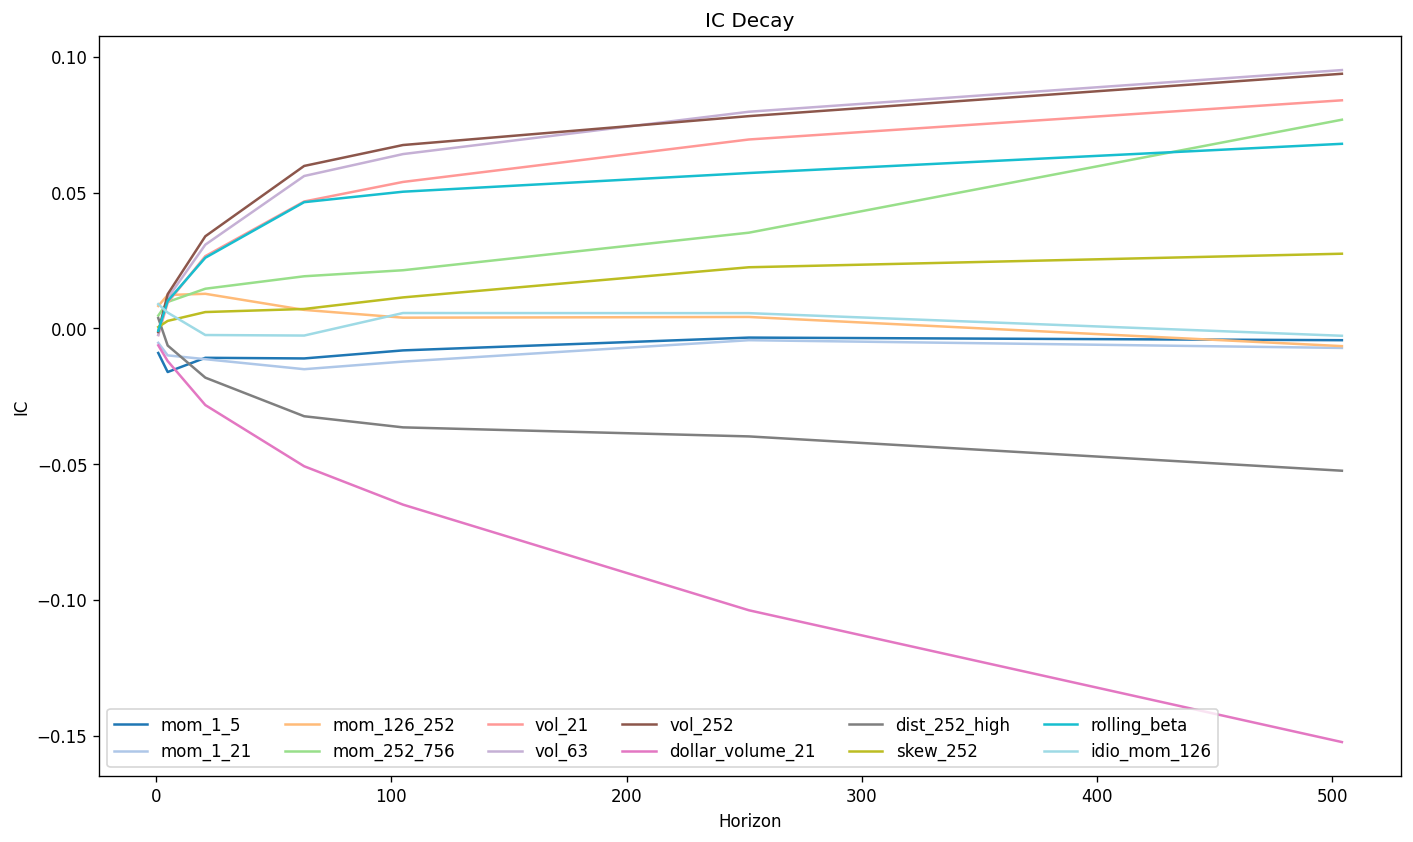

In [17]:
from cycler import cycler

colors = plt.cm.get_cmap("tab20", len(FEATURE_COLS))
plt.rcParams["axes.prop_cycle"] = cycler(color=[colors(i) for i in range(len(FEATURE_COLS))])
plt.figure(figsize=(14, 8), dpi=120)
for x in FEATURE_COLS:
    plt.plot(ic_decay_df.loc[x], label = x)
plt.legend(ncols = 6)
plt.xlabel("Horizon")
plt.ylabel("IC")
plt.title("IC Decay")
plt.show()

In [19]:
ic_decay_df

,1,5,21,63,105,252,504
mom_1_5,-0.009053,-0.016070,-0.010835,-0.011066,-0.008102,-0.003387,-0.004350
mom_1_21,-0.005325,-0.009936,-0.011340,-0.015030,-0.012234,-0.004347,-0.007200
mom_126_252,0.008261,0.012297,0.012743,0.006818,0.003947,0.004212,-0.006529
mom_252_756,0.004715,0.009743,0.014611,0.019197,0.021422,0.035256,0.076870
vol_21,-0.002408,0.009499,0.026615,0.046743,0.053948,0.069586,0.084017
vol_63,-0.002447,0.011179,0.030840,0.056134,0.064209,0.079801,0.095156
vol_252,-0.001316,0.012606,0.033935,0.059839,0.067543,0.078192,0.093794
dollar_volume_21,-0.006246,-0.012024,-0.028243,-0.050781,-0.064917,-0.103831,-0.152377
dist_252_high,0.003792,-0.006307,-0.018144,-0.032360,-0.036458,-0.039787,-0.052428
skew_252,0.000497,0.002757,0.006019,0.007152,0.011415,0.022520,0.027508


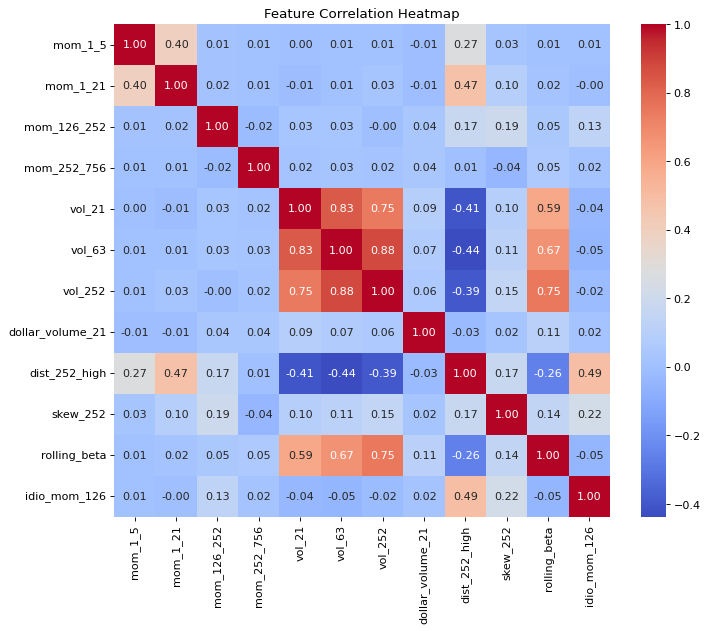

In [18]:
CORRELATION_STRUCTURE = df[FEATURE_COLS].corr()

#feature x feature correlation heatmap
plt.figure(figsize=(10, 8), dpi=80)
sns.heatmap(df[FEATURE_COLS].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

- `dollar_volume_21` and `dollar_volume_63` are perfectly correlated and have the same `ic_decay`, so we can drop one of them;
- `downside_dev_252` is also highly correlated with `vol_252`, so we can also drop one of them;


* From the ic time structure:

* Short-term (5 days):   `mom_1_5`, `mom_1_21`

* Medium-term (21 days): `mom_126_252`

* Long-term (126-252d):  `mom_252_756`, `vol_21`, `vol_63`, `vol_252`,
                       `dollar_volume_21`, `dist_252_high`, `max_21`, `skew_252`


dropping: `mom_21_126`, `mom_21_252`, `dollar_volume_63`, `downside_dev_21`, `downside_dev_63`, `downside_dev_252`

In [ ]:
FEATURES_SHORT_TERM  = ['mom_1_5', 'mom_1_21', 'idiosyncratic']
FEATURES_MEDIUM_TERM = ['mom_126_252']
FEATURES_LONG_TERM   = ['mom_252_756', 'vol_21', 'vol_63', 'vol_252',
                        'dollar_volume_21', 'dist_252_high', 'max_21', 'skew_252', 'rolling_beta']
FEATURES_COLS = FEATURES_SHORT_TERM + FEATURES_MEDIUM_TERM + FEATURES_LONG_TERM

In [ ]:
FEATURES_COLS

In [ ]:
CORRELATION_STRUCTURE = df[FEATURES_COLS].corr()

#feature x feature correlation heatmap
plt.figure(figsize=(10, 8), dpi=80)
sns.heatmap(CORRELATION_STRUCTURE, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()